# Kohonen Self-Organizing Map (SOM) for Street Risk Analysis

This notebook trains a SOM on street features (lighting, visibility, connectivity, enclosure) and analyzes how different street types correlate with **safety risk** in London boroughs.

**Key insight**: While individual features have weak correlation with crime count, feature *combinations* (identified by SOM clustering) show meaningful patterns.

## Setup & Data Loading

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import seaborn as sns
from minisom import MiniSom
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Load data
df = pd.read_csv('C:\\Users\\maria\\Documents\\GitHub\\MaCAD26-G01-DataEncoding\\csv\\segment_risk_scores_w-id.csv')

print(f"✓ Loaded {len(df):,} street segments")
print(f"✓ Boroughs: {df['borough'].nunique()}")
print(f"\nData shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

✓ Loaded 35,978 street segments
✓ Boroughs: 5

Data shape: (35978, 16)

Columns: ['borough', 'lighting', 'lighting_norm', 'visibility', 'visibility_norm', 'connectivity', 'connectivity_norm', 'enclosure', 'enclosure_norm', 'public_transport_proximity_m', 'public_transport_proximity_m_norm', 'dominant_land_use_score', 'dominant_land_use_score_norm', 'risk_score', 'risk_class', 'location_id']


In [18]:
import os

# Create output directory for SOM plots
output_dir = r'C:\Users\maria\Documents\GitHub\MaCAD26-G01-DataEncoding\notebooks\plots\kohonen'
os.makedirs(output_dir, exist_ok=True)
print(f"✓ Output directory ready: {output_dir}")

✓ Output directory ready: C:\Users\maria\Documents\GitHub\MaCAD26-G01-DataEncoding\notebooks\plots\kohonen


## Feature Analysis

In [19]:
# Feature summary
features = ['lighting', 'visibility', 'connectivity', 'enclosure', 'public_transport_proximity_m', 'dominant_land_use_score']

print("Feature Statistics:")
print(df[features + ['risk_score']].describe().round(3))

# Correlations with crime
print("\n" + "="*60)
print("Feature-Crime Correlations:")
print("="*60)
for feat in features:
    corr = df[feat].corr(df['risk_score'])
    print(f"{feat:15} r = {corr:7.4f}")

Feature Statistics:
        lighting  visibility  connectivity  enclosure  \
count  35978.000   35978.000     35978.000  35978.000   
mean       2.070       0.704        10.431      0.287   
std        5.956       0.115         2.326      0.150   
min        0.000       0.247         3.000      0.000   
25%        0.000       0.646         8.000      0.195   
50%        0.000       0.721        11.000      0.272   
75%        1.234       0.777        12.000      0.367   
max      163.390       1.000        17.000      1.136   

       public_transport_proximity_m  dominant_land_use_score  risk_score  
count                     35978.000                35903.000   35978.000  
mean                        110.696                    0.310       0.479  
std                          75.332                    0.192       0.119  
min                           0.450                    0.000       0.000  
25%                          53.940                    0.152       0.396  
50%             

## Prepare Data for SOM

In [20]:
# Extract features and standardize
X = df[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Training data shape: {X_scaled.shape}")
print(f"Features: {', '.join(features)}")
print(f"\nScaled feature statistics:")
print(f"  Mean: {X_scaled.mean(axis=0).round(3)}")
print(f"  Std:  {X_scaled.std(axis=0).round(3)}")

Training data shape: (35978, 6)
Features: lighting, visibility, connectivity, enclosure, public_transport_proximity_m, dominant_land_use_score

Scaled feature statistics:
  Mean: [ 0.  0.  0. -0. -0. nan]
  Std:  [ 1.  1.  1.  1.  1. nan]


## Train Kohonen SOM

We use an 8×6 grid (48 clusters) to organize street segments into archetypal street types.
Similar streets cluster together, allowing us to see which street types correlate with crime.

In [21]:
print("Training SOM (8×6 grid = 48 clusters)...")

# Initialize and train SOM
som = MiniSom(x=8, y=6, input_len=len(features), sigma=1.5, learning_rate=0.5)
som.train(X_scaled, num_iteration=100, verbose=False)

print("✓ Training complete")

# Get winning neuron for each segment
winners = np.array([som.winner(x) for x in X_scaled])
df['som_x'] = winners[:, 0]
df['som_y'] = winners[:, 1]
df['som_cluster'] = df['som_x'].astype(str) + '_' + df['som_y'].astype(str)

print(f"✓ Segments assigned to {df['som_cluster'].nunique()} unique clusters")
print(f"\nCluster distribution:")
print(df['som_cluster'].value_counts().sort_index())

Training SOM (8×6 grid = 48 clusters)...
✓ Training complete
✓ Segments assigned to 48 unique clusters

Cluster distribution:
som_cluster
0_0     521
0_1     376
0_2     122
0_3      70
0_4     238
0_5    1347
1_0     221
1_1     331
1_2    2902
1_3     113
1_4     126
1_5     168
2_0    1635
2_1     249
2_2     835
2_3     187
2_4     176
2_5    2007
3_0     312
3_1     581
3_2     560
3_3     688
3_4     412
3_5     317
4_0     577
4_1     229
4_2    1100
4_3     597
4_4    2959
4_5     971
5_0    1084
5_1    1400
5_2     507
5_3     880
5_4     899
5_5     993
6_0    2181
6_1     272
6_2     365
6_3      24
6_4     348
6_5     945
7_0    3547
7_1     589
7_2     252
7_3     140
7_4     186
7_5     439
Name: count, dtype: int64


## Cluster Analysis: Risk by Street Type

In [22]:
# Analyze clusters
cluster_stats = []

for cluster in sorted(df['som_cluster'].unique()):
    cluster_data = df[df['som_cluster'] == cluster]
    
    cluster_stats.append({
        'cluster': cluster,
        'n_segments': len(cluster_data),
        'risk_mean': cluster_data['risk_score'].mean(),
        'risk_median': cluster_data['risk_score'].median(),
        'risk_std': cluster_data['risk_score'].std(),
        'risk_max': cluster_data['risk_score'].max(),
        'lighting_mean': cluster_data['lighting'].mean(),
        'visibility_mean': cluster_data['visibility'].mean(),
        'connectivity_mean': cluster_data['connectivity'].mean(),
        'enclosure_mean': cluster_data['enclosure'].mean(),
        'transport_mean': cluster_data['public_transport_proximity_m'].mean(),
        'land_use_mean': cluster_data['dominant_land_use_score'].mean(),
        'zero_risk_pct': (cluster_data['risk_score'] == 0).sum() / len(cluster_data) * 100,
    })

cluster_df = pd.DataFrame(cluster_stats)
cluster_df = cluster_df.sort_values('risk_mean', ascending=False)

print("\n" + "="*100)
print("TOP 15 HIGHEST RISK CLUSTERS")
print("="*100)
display(cluster_df.head(15)[['cluster', 'n_segments', 'risk_mean', 'risk_median', 
                               'lighting_mean', 'visibility_mean', 'connectivity_mean', 
                               'enclosure_mean']].round(3))

print("\n" + "="*100)
print("TOP 15 LOWEST RISK CLUSTERS")
print("="*100)
display(cluster_df.tail(15)[['cluster', 'n_segments', 'risk_mean', 'risk_median', 
                               'lighting_mean', 'visibility_mean', 'connectivity_mean', 
                               'enclosure_mean']].round(3))


TOP 15 HIGHEST RISK CLUSTERS


,cluster,n_segments,risk_mean,risk_median,lighting_mean,visibility_mean,connectivity_mean,enclosure_mean
5,0_5,1347,0.616,0.606,1.837,0.517,8.143,0.442
21,3_3,688,0.602,0.598,0.679,0.665,8.445,0.420
20,3_2,560,0.594,0.583,0.281,0.661,9.434,0.386
30,5_0,1084,0.588,0.567,0.599,0.673,12.193,0.352
8,1_2,2902,0.588,0.583,1.436,0.494,10.460,0.570
31,5_1,1400,0.581,0.583,0.742,0.765,9.396,0.205
26,4_2,1100,0.569,0.568,0.540,0.760,8.275,0.220
25,4_1,229,0.560,0.533,2.774,0.696,10.511,0.312
29,4_5,971,0.546,0.549,0.673,0.706,8.577,0.246
17,2_5,2007,0.545,0.541,0.951,0.688,7.120,0.269



TOP 15 LOWEST RISK CLUSTERS


,cluster,n_segments,risk_mean,risk_median,lighting_mean,visibility_mean,connectivity_mean,enclosure_mean
43,7_1,589,0.401,0.400,0.214,0.772,12.171,0.225
2,0_2,122,0.383,0.387,0.226,0.656,11.869,0.345
35,5_5,993,0.379,0.380,2.744,0.754,11.077,0.155
6,1_0,221,0.377,0.379,3.888,0.669,12.615,0.331
1,0_1,376,0.362,0.364,0.454,0.698,12.346,0.305
47,7_5,439,0.352,0.358,0.324,0.767,12.503,0.259
44,7_2,252,0.342,0.341,0.493,0.754,14.071,0.231
0,0_0,521,0.337,0.342,2.190,0.683,13.512,0.301
41,6_5,945,0.334,0.335,0.568,0.754,12.428,0.194
33,5_3,880,0.313,0.324,0.497,0.828,11.630,0.135


## Key Insights: What Distinguishes High vs Low Risk Streets?

In [23]:
# Compare top 5 vs bottom 5 clusters
high_risk = cluster_df.head(5)
low_risk = cluster_df.tail(5)

print("\n" + "="*80)
print("HIGH-RISK STREET TYPES (Top 5 clusters)")
print("="*80)
print(f"Average risk_score: {high_risk['risk_mean'].mean():.2f}")
print(f"Average n_segments:  {high_risk['n_segments'].mean():.0f}")
print(f"\nTypical street profile:")
print(f"  • Enclosure (building coverage):  {high_risk['enclosure_mean'].mean():.3f}")
print(f"  • Lighting (lamps/100m):          {high_risk['lighting_mean'].mean():.2f}")
print(f"  • Connectivity (node degree):     {high_risk['connectivity_mean'].mean():.1f}")
print(f"  • Visibility (building height):   {high_risk['visibility_mean'].mean():.1f}m")
print(f"  • Transport (public transport proximity):   {high_risk['transport_mean'].mean():.1f}m")
print(f"  • Land-use (dominant land use score):   {high_risk['land_use_mean'].mean():.1f}")
print(f"  • Zero risk: {high_risk['zero_risk_pct'].mean():.0f}%")

print("\n" + "="*80)
print("LOW-RISK STREET TYPES (Bottom 5 clusters)")
print("="*80)
print(f"Average risk_score: {low_risk['risk_mean'].mean():.2f}")
print(f"Average n_segments:  {low_risk['n_segments'].mean():.0f}")
print(f"\nTypical street profile:")
print(f"  • Enclosure (building coverage):  {low_risk['enclosure_mean'].mean():.3f}")
print(f"  • Lighting (lamps/100m):          {low_risk['lighting_mean'].mean():.2f}")
print(f"  • Connectivity (node degree):     {low_risk['connectivity_mean'].mean():.1f}")
print(f"  • Visibility (building height):   {low_risk['visibility_mean'].mean():.1f}m")
print(f"  • Transport (public transport proximity):   {low_risk['transport_mean'].mean():.1f}m")
print(f"  • Land-use (dominant land use score):   {low_risk['land_use_mean'].mean():.1f}")
print(f"  • Zero risk: {low_risk['zero_risk_pct'].mean():.0f}%")

print("\n" + "="*80)
print("KEY DIFFERENCES (High Risk - Low Risk)")
print("="*80)
diff_enc = high_risk['enclosure_mean'].mean() - low_risk['enclosure_mean'].mean()
diff_lit = high_risk['lighting_mean'].mean() - low_risk['lighting_mean'].mean()
diff_conn = high_risk['connectivity_mean'].mean() - low_risk['connectivity_mean'].mean()
diff_vis = high_risk['visibility_mean'].mean() - low_risk['visibility_mean'].mean()
diff_trans = high_risk['transport_mean'].mean() - low_risk['transport_mean'].mean()
diff_land = high_risk['land_use_mean'].mean() - low_risk['land_use_mean'].mean()


print(f"  ✓ ENCLOSURE:    {diff_enc:+.3f}  (HIGH-RISK streets are MORE enclosed/covered)")
print(f"  ✓ CONNECTIVITY: {diff_conn:+.1f}   (HIGH-RISK streets are MORE connected/complex)")
print(f"  • Visibility:   {diff_vis:+.1f}  (higher buildings in high-risk)")
print(f"  • Lighting:     {diff_lit:+.2f}  (slightly more lamps in high-risk)")
print(f"  • Transport:    {diff_trans:+.1f}  (higher public transport proximity in high-risk)")
print(f"  • Land-use:      {diff_land:+.1f}  (higher dominant land use score in high-risk)")


HIGH-RISK STREET TYPES (Top 5 clusters)
Average risk_score: 0.60
Average n_segments:  1316

Typical street profile:
  • Enclosure (building coverage):  0.434
  • Lighting (lamps/100m):          0.97
  • Connectivity (node degree):     9.7
  • Visibility (building height):   0.6m
  • Transport (public transport proximity):   140.9m
  • Land-use (dominant land use score):   0.4
  • Zero risk: 0%

LOW-RISK STREET TYPES (Bottom 5 clusters)
Average risk_score: 0.27
Average n_segments:  319

Typical street profile:
  • Enclosure (building coverage):  0.183
  • Lighting (lamps/100m):          0.78
  • Connectivity (node degree):     13.7
  • Visibility (building height):   0.8m
  • Transport (public transport proximity):   84.0m
  • Land-use (dominant land use score):   0.4
  • Zero risk: 0%

KEY DIFFERENCES (High Risk - Low Risk)
  ✓ ENCLOSURE:    +0.251  (HIGH-RISK streets are MORE enclosed/covered)
  ✓ CONNECTIVITY: -3.9   (HIGH-RISK streets are MORE connected/complex)
  • Visibility:   -

## Visualize SOM Grid: Risk Heatmap

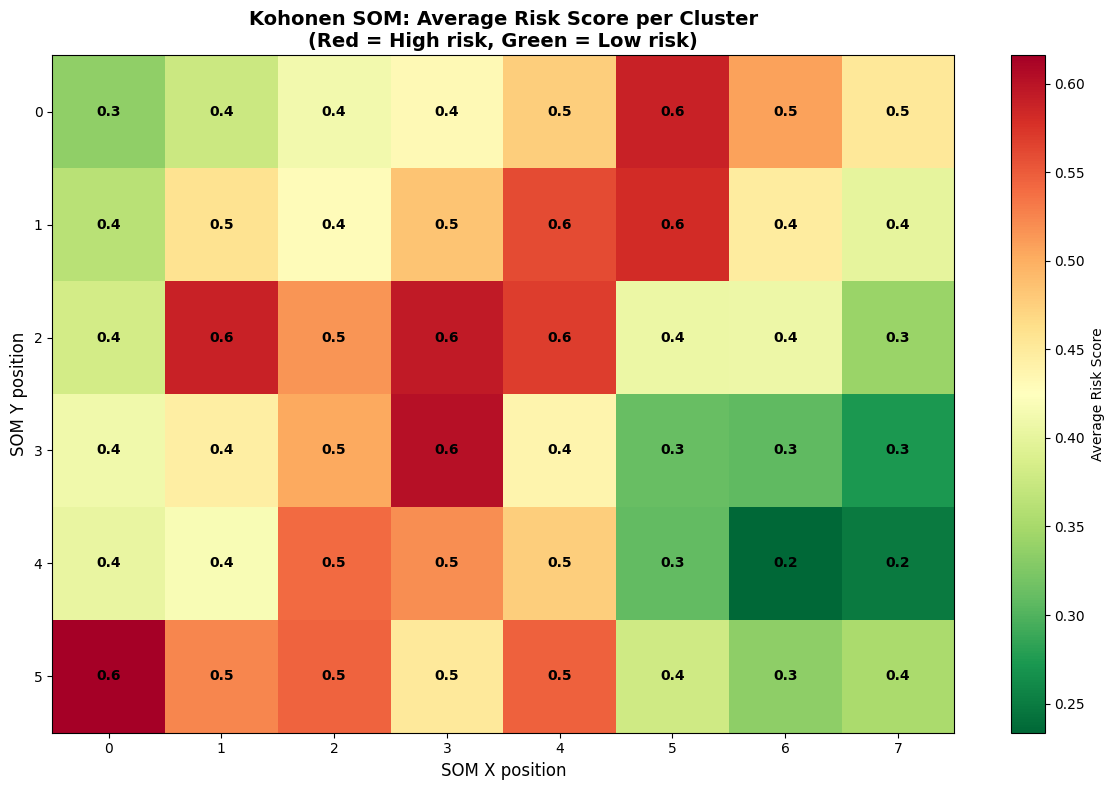

✓ Heatmap saved to C:\Users\maria\Documents\GitHub\MaCAD26-G01-DataEncoding\notebooks\plots\kohonen\som_heatmap.png


In [24]:
# Create a 2D grid showing risk_score for each SOM cell
som_grid = np.zeros((6, 8))
som_counts = np.zeros((6, 8))

for idx, row in df.iterrows():
    x, y = int(row['som_x']), int(row['som_y'])
    som_grid[y, x] += row['risk_score']
    som_counts[y, x] += 1

# Average crime per cell
som_avg = np.divide(som_grid, som_counts, where=som_counts!=0, out=np.zeros_like(som_grid))

# Visualize
fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(som_avg, cmap='RdYlGn_r', aspect='auto')

# Add values to cells
for y in range(6):
    for x in range(8):
        text = ax.text(x, y, f'{som_avg[y, x]:.1f}',
                       ha="center", va="center", color="black", fontsize=10, fontweight='bold')

ax.set_xticks(range(8))
ax.set_yticks(range(6))
ax.set_xticklabels(range(8))
ax.set_yticklabels(range(6))
ax.set_xlabel('SOM X position', fontsize=12)
ax.set_ylabel('SOM Y position', fontsize=12)
ax.set_title('Kohonen SOM: Average Risk Score per Cluster\n(Red = High risk, Green = Low risk)', 
             fontsize=14, fontweight='bold')

cbar = plt.colorbar(im, ax=ax, label='Average Risk Score')
plt.tight_layout()
heatmap_path = os.path.join(output_dir, 'som_heatmap.png')
plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Heatmap saved to {heatmap_path}")

## Visualize SOM Feature Weights

In [25]:
# Check if there are NaN values
weights_all = som.get_weights()
print(f"Shape: {weights_all.shape}")
print(f"Any NaN values? {np.isnan(weights_all).any()}")
print(f"NaN count per feature:")
for i, feature in enumerate(['lighting', 'visibility', 'connectivity', 'enclosure', 'dominant_land_use_score', 'public_transport_proximity_m']):
    nan_count = np.isnan(weights_all[:, :, i]).sum()
    print(f"  {feature}: {nan_count}")

Shape: (8, 6, 6)
Any NaN values? False
NaN count per feature:
  lighting: 0
  visibility: 0
  connectivity: 0
  enclosure: 0
  dominant_land_use_score: 0
  public_transport_proximity_m: 0


In [26]:
# Debug: Print all weight values to see what should be displayed
feature_list = ['lighting', 'visibility', 'connectivity', 'enclosure', 'dominant_land_use_score', 'public_transport_proximity_m']
 
for idx, feature in enumerate(feature_list):
    weights = som.get_weights()[:, :, idx]
    print(f"\n{feature.upper()} - Shape: {weights.shape}")
    print(f"Min: {weights.min():.2f}, Max: {weights.max():.2f}")
    print("Values by position (x, y):")
    for y in range(weights.shape[1]):
        row = []
        for x in range(weights.shape[0]):
            val = weights[x, y]
            row.append(f"{val:6.2f}")
        print(f"y={y}: " + "  ".join(row))
    print()
 


LIGHTING - Shape: (8, 6)
Min: -0.32, Max: 0.89
Values by position (x, y):
y=0:  -0.09    0.31    0.89    0.19   -0.17   -0.11    0.04   -0.02
y=1:  -0.05   -0.04    0.11    0.01   -0.01   -0.13   -0.07   -0.19
y=2:  -0.25   -0.29   -0.28   -0.21   -0.14   -0.26   -0.27   -0.27
y=3:  -0.27   -0.27   -0.21   -0.11   -0.17   -0.29   -0.26   -0.32
y=4:  -0.25   -0.21   -0.17    0.09    0.04   -0.13   -0.10   -0.24
y=5:  -0.24   -0.23   -0.17    0.11   -0.04    0.09   -0.14   -0.17


VISIBILITY - Shape: (8, 6)
Min: -1.20, Max: 0.72
Values by position (x, y):
y=0:  -0.62   -0.33   -0.27    0.09    0.07    0.14    0.34    0.41
y=1:  -0.28   -0.46   -0.23    0.06    0.31    0.45    0.44    0.48
y=2:  -0.43   -1.18   -0.44   -0.01    0.35    0.53    0.42    0.54
y=3:  -0.44   -0.55   -0.34   -0.15    0.27    0.72    0.66    0.63
y=4:  -0.93   -0.67   -0.51   -0.20    0.31    0.58    0.71    0.65
y=5:  -1.20   -0.95   -0.41   -0.35    0.01    0.13    0.29    0.51


CONNECTIVITY - Shape: (8, 6)


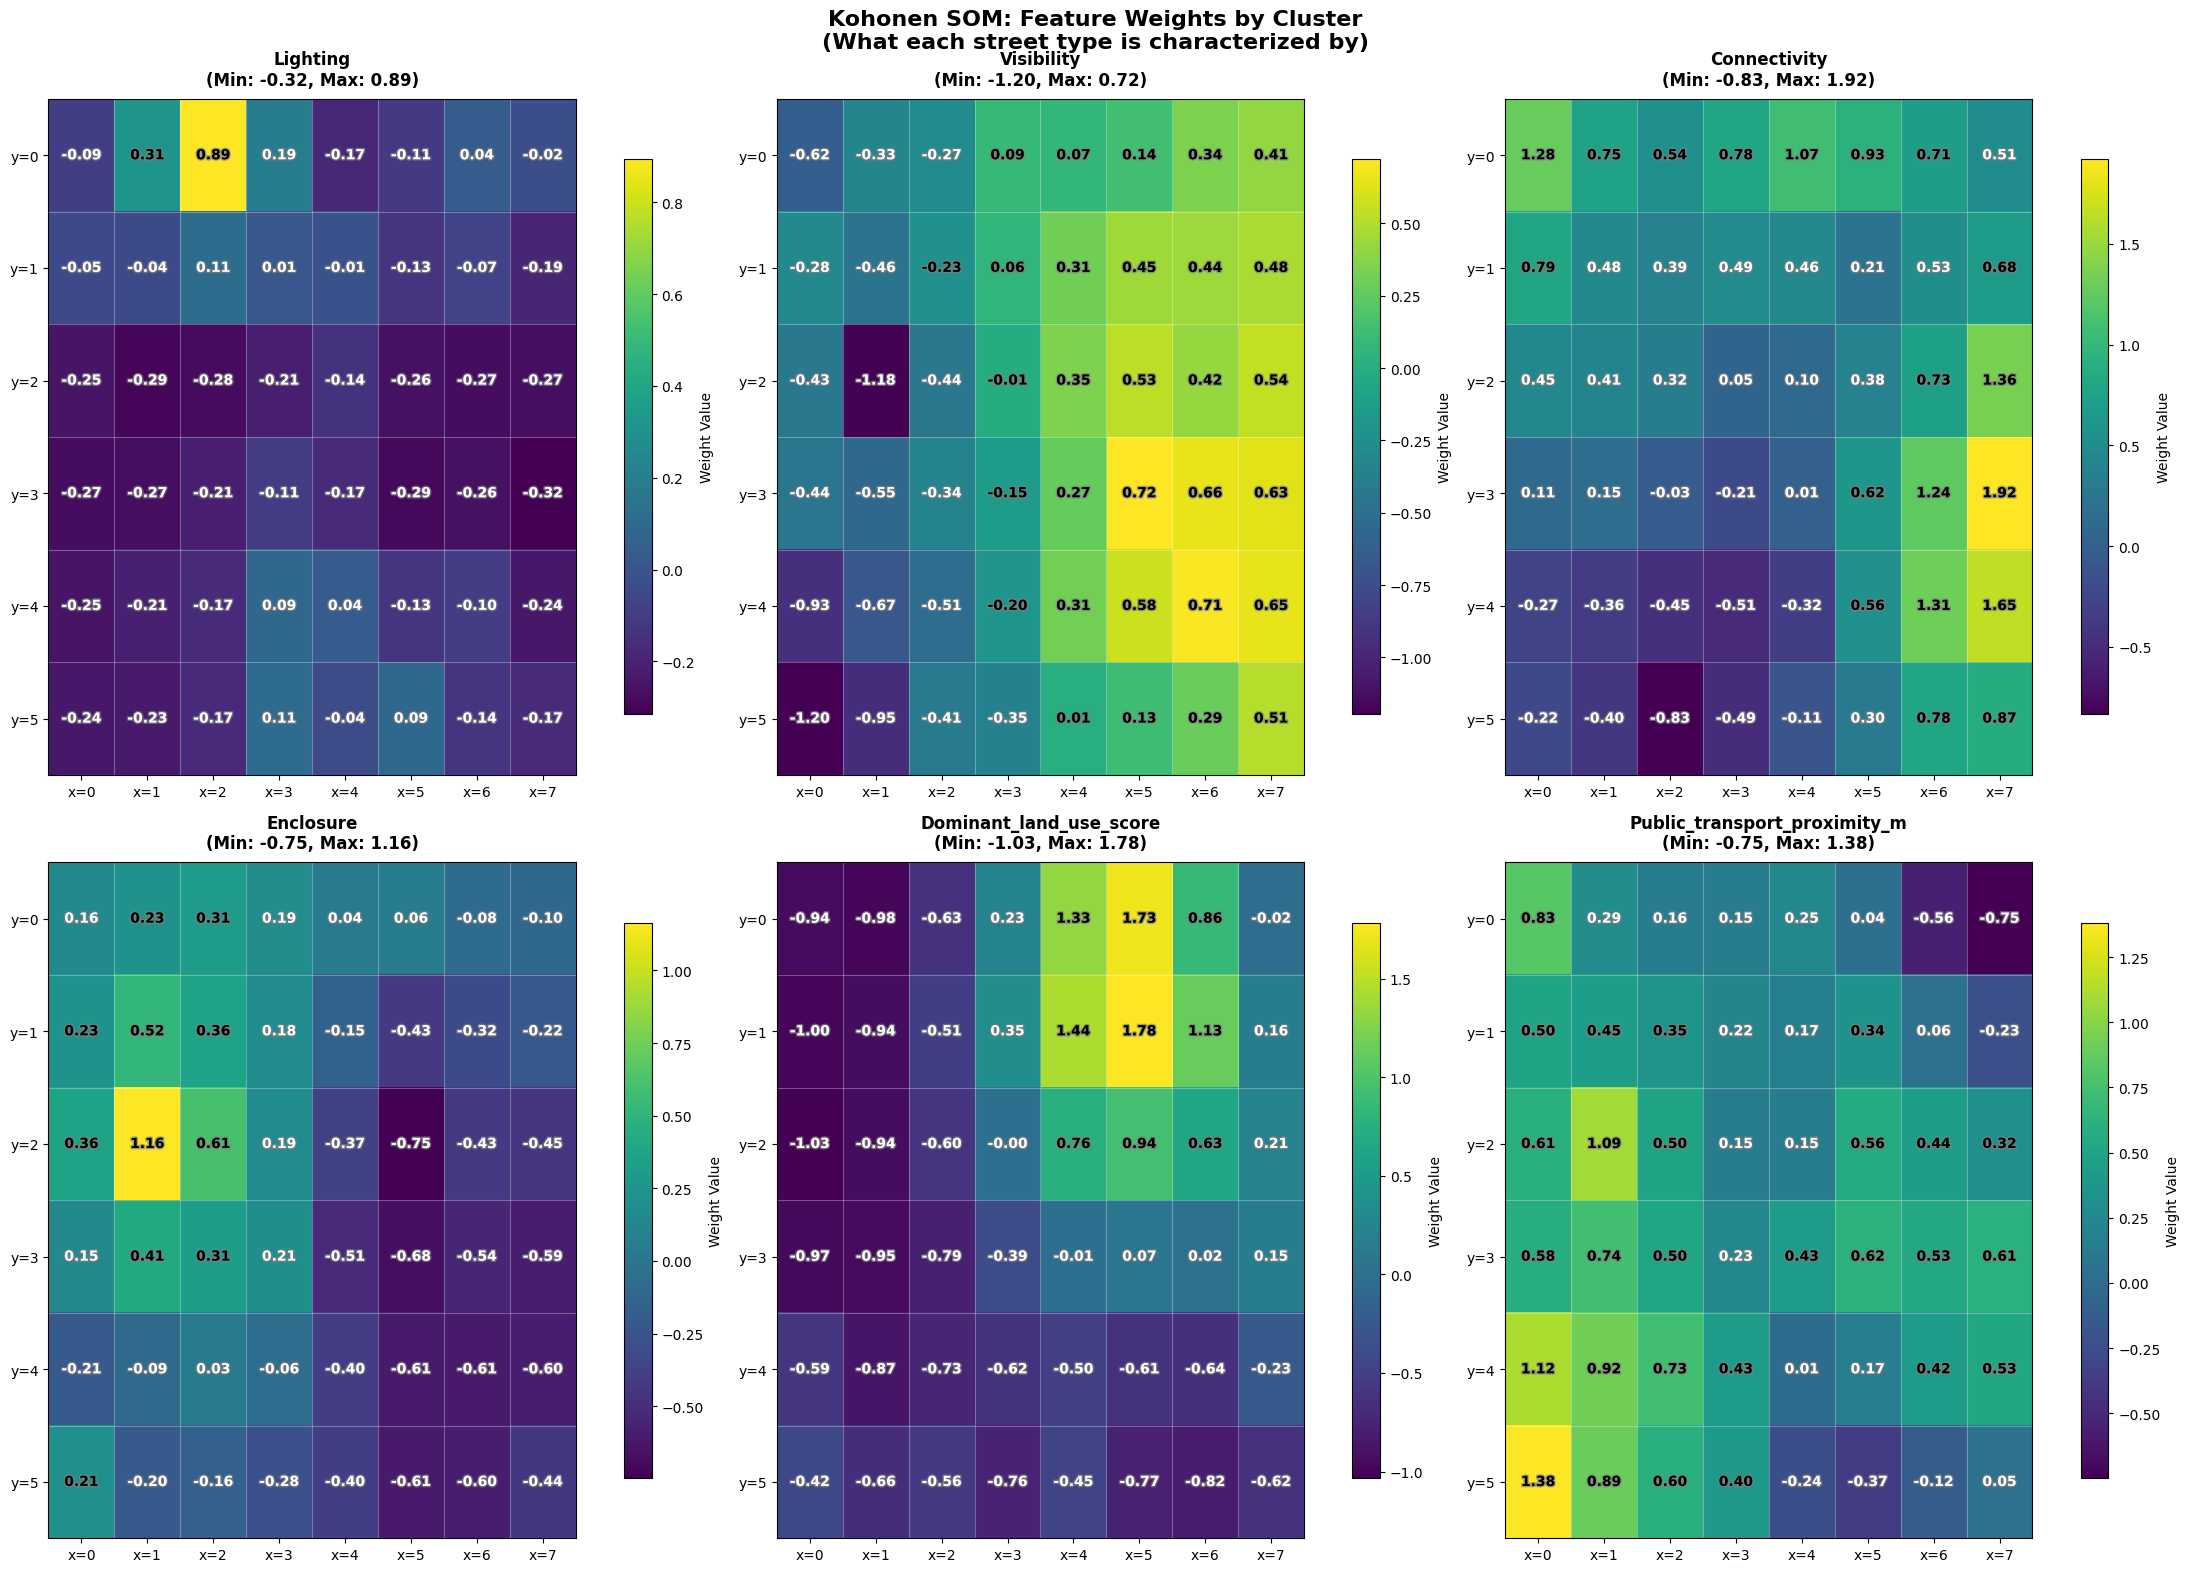

✓ Feature weights saved to C:\Users\maria\Documents\GitHub\MaCAD26-G01-DataEncoding\notebooks\plots\kohonen\som_weights.png


In [27]:
fig, axes = plt.subplots(2, 3, figsize=(22, 16))
fig.suptitle('Kohonen SOM: Feature Weights by Cluster\n(What each street type is characterized by)', 
             fontsize=16, fontweight='bold', y=0.98)

feature_list = ['lighting', 'visibility', 'connectivity', 'enclosure', 'dominant_land_use_score', 'public_transport_proximity_m']

for idx, (ax, feature) in enumerate(zip(axes.flat, feature_list)):
    # Get weights for this feature and TRANSPOSE
    weights = som.get_weights()[:, :, idx].T  # Now shape is (6, 8) for imshow
    
    # Draw heatmap
    im = ax.imshow(weights, cmap='viridis', aspect='auto', interpolation='nearest')
    
    # Add text values - iterate through actual dimensions
    for y in range(weights.shape[0]):  # y: 0-5 (6 rows)
        for x in range(weights.shape[1]):  # x: 0-7 (8 columns)
            val = weights[y, x]
            
            # Determine text color based on normalized brightness
            norm_val = (val - weights.min()) / (weights.max() - weights.min() + 1e-10)
            text_color = "white" if norm_val < 0.5 else "black"
            
            # Add text with proper styling
            ax.text(x, y, f'{val:.2f}', 
                   ha="center", va="center", 
                   color=text_color, 
                   fontsize=10, 
                   fontweight='bold',
                   path_effects=[path_effects.withStroke(linewidth=2, 
                                                         foreground='gray', 
                                                         alpha=0.7)])
    
    # Styling
    ax.set_xticks(range(weights.shape[1]))
    ax.set_yticks(range(weights.shape[0]))
    ax.set_xticklabels([f'x={i}' for i in range(weights.shape[1])], fontsize=10)
    ax.set_yticklabels([f'y={i}' for i in range(weights.shape[0])], fontsize=10)
    ax.set_title(f'{feature.capitalize()}\n(Min: {weights.min():.2f}, Max: {weights.max():.2f})', 
                fontweight='bold', fontsize=12, pad=10)
    
    # Add colorbar with proper spacing to avoid text overlap
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.08)
    cbar.set_label('Weight Value', fontsize=10)
    
    # Grid for better readability
    for i in range(weights.shape[1] + 1):
        ax.axvline(i - 0.5, color='white', linestyle='-', linewidth=0.8, alpha=0.3)
    for j in range(weights.shape[0] + 1):
        ax.axhline(j - 0.5, color='white', linestyle='-', linewidth=0.8, alpha=0.3)

plt.tight_layout()
weights_path = os.path.join(output_dir, 'som_weights.png')
plt.savefig(weights_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Feature weights saved to {weights_path}")

In [28]:
# First, check which neurons have segments assigned
print("Checking neuron occupancy...")
neuron_counts = np.zeros((6, 8))
for idx, row in df.iterrows():
    x, y = int(row['som_x']), int(row['som_y'])
    neuron_counts[y, x] += 1

used_neurons = np.sum(neuron_counts > 0)
total_neurons = 8 * 6
print(f"Neurons with segments: {used_neurons}/{total_neurons}")
print(f"\nSegments per neuron:")
print(neuron_counts.astype(int))

Checking neuron occupancy...
Neurons with segments: 48/48

Segments per neuron:
[[ 521  221 1635  312  577 1084 2181 3547]
 [ 376  331  249  581  229 1400  272  589]
 [ 122 2902  835  560 1100  507  365  252]
 [  70  113  187  688  597  880   24  140]
 [ 238  126  176  412 2959  899  348  186]
 [1347  168 2007  317  971  993  945  439]]


## Visualize Distribution of Clusters by Risk

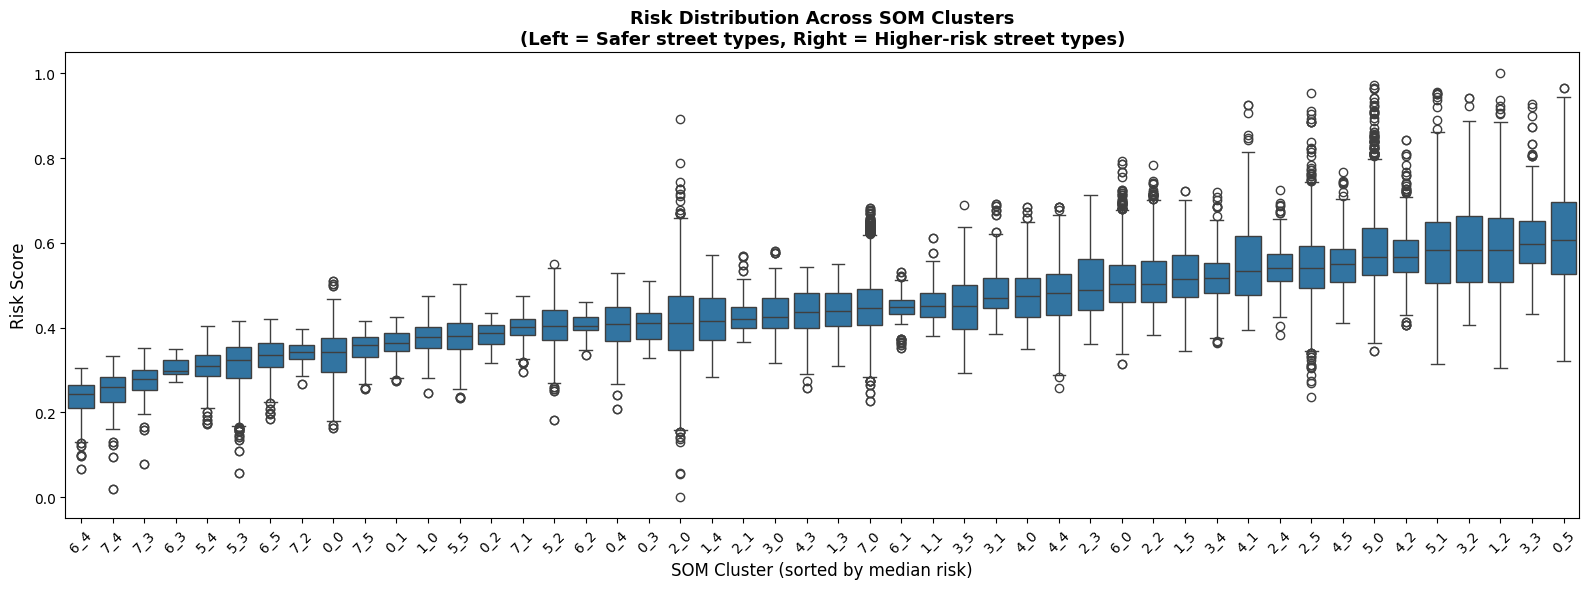

✓ Box plot saved to C:\Users\maria\Documents\GitHub\MaCAD26-G01-DataEncoding\notebooks\plots\kohonen\som_clusters_boxplot.png


In [29]:
# Box plot of risk by SOM cluster
fig, ax = plt.subplots(figsize=(16, 6))

# Sort clusters by median risk to ensure left-to-right ordering from safer to riskier
cluster_order = cluster_df.sort_values('risk_median')['cluster'].tolist()

sns.boxplot(data=df, x='som_cluster', y='risk_score', order=cluster_order, ax=ax)
ax.set_xlabel('SOM Cluster (sorted by median risk)', fontsize=12)
ax.set_ylabel('Risk Score', fontsize=12)
ax.set_title('Risk Distribution Across SOM Clusters\n(Left = Safer street types, Right = Higher-risk street types)', 
             fontsize=13, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
boxplot_path = os.path.join(output_dir, 'som_clusters_boxplot.png')
plt.savefig(boxplot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Box plot saved to {boxplot_path}")

## Geographic Distribution of Street Types

In [30]:
# Show which boroughs have which street types
print("\nSOM Cluster Distribution by Borough:")
print("="*100)

cluster_by_borough = pd.crosstab(df['borough'], df['som_cluster'], margins=True)
print(cluster_by_borough)


SOM Cluster Distribution by Borough:
som_cluster                                  0_0  0_1  0_2  0_3  0_4   0_5  \
borough                                                                      
City of Westminster, London, UK              119   46   10    7   75   632   
London Borough of Hackney, London, UK        107   80   32    6   24   137   
London Borough of Islington, London, UK      102   94   32   23   38   170   
London Borough of Southwark, London, UK      120   82   21   18   60   176   
London Borough of Tower Hamlets, London, UK   73   74   27   16   41   232   
All                                          521  376  122   70  238  1347   

som_cluster                                  1_0  1_1   1_2  1_3  ...  6_3  \
borough                                                           ...        
City of Westminster, London, UK               48  107  1758   34  ...    2   
London Borough of Hackney, London, UK         56   46   228   13  ...    6   
London Borough of Islingt

## Export Results

In [31]:
# Save full dataset with SOM assignments
# Use only columns that exist in the dataframe
available_cols = ['borough', 'location_id', 'lighting', 'visibility', 
                  'connectivity', 'enclosure', 'risk_score', 'dominant_land_use_score', 'public_transport_proximity_m', 
                  'som_cluster', 'som_x', 'som_y']

df_export = df[available_cols].copy()
project_root = os.getcwd()
if not os.path.isdir(os.path.join(project_root, 'csv')) and os.path.isdir(os.path.join(os.path.dirname(project_root), 'csv')):
    project_root = os.path.dirname(project_root)

csv_dir = os.path.join(project_root, 'csv')
os.makedirs(csv_dir, exist_ok=True)

df_export.to_csv(os.path.join(csv_dir, 'features_with_som_clusters.csv'), index=False)
print(f"✓ Saved {len(df_export):,} segments with SOM assignments")

# Save cluster statistics
cluster_df.to_csv(os.path.join(csv_dir, 'som_cluster_statistics.csv'), index=False)
print(f"✓ Saved cluster statistics (48 clusters)")

print("\n✓ Export complete!")

✓ Saved 35,978 segments with SOM assignments
✓ Saved cluster statistics (48 clusters)

✓ Export complete!
